# Part 9: Power Transformations {-}

In this brief part we will consider families of transforming a sample with the explicit objective of maximizing the quality of the fit of a normal distribution to that sample.

The motivations for such a transformation include (1) to make a skewed distribution more symmetric and "nice"; (2) to allow for the use of the normal model in a case where it otherwise may not be clear how to model the variable; and (3) to transform the response of a regression model so that the normal approximation is a better fit for the model error.

\newpage

## Box-Cox Transformation {-}

This is **only** useful in the case where the response is **strictly
positive**.

Define Box-Cox **power transformation** function:
\begin{equation*}
   y^{(\lambda)} = \left\{
   \begin{array}{ll}
   \frac{y^{\lambda}-1}{\lambda} & \mbox{if $\lambda \neq 0$} \\
   \log(y) & \mbox{if $\lambda = 0$}
   \end{array}
   \right.
\end{equation*}

This defines a wide range of possible transformations for the response, including
$\sqrt{y}$, $y^2$, $\log(y)$, $1/\sqrt{y}$, and so forth.

**Exercise:** Why is the case $\lambda \neq 0$ defined in the manner it is, instead of just as $y^{\lambda}$?

\answerlines{10}

\newpage

In Python, this is implemented via the function `boxcox()`, which is part of the
package `scipy.stats`.

In [1]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

Let's start with a synthetic example.

In [2]:
x = np.random.gamma(1,4,100)

We note that this is far from a normal shape.

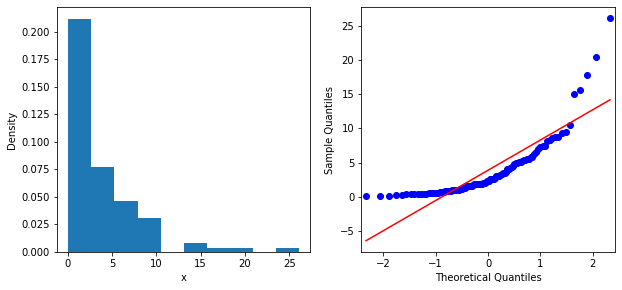

In [3]:
from statsmodels.graphics.gofplots import qqplot

fig, axs = plt.subplots(1, 2, figsize=[10,4.5])
axs[0].hist(x,density=True)
axs[0].set_xlabel("x")
axs[0].set_ylabel("Density")

qqplot(x,line="s",ax=axs[1])
plt.show()

Now we call the `boxcox` function. By specifying `lmbda=None`, we ask the procedure to find the optimal value of $\lambda$ via maximum likelihood. Specifying `alpha=0.05` means that the procedure will return a 95% confidence interval for $\lambda$.

In [4]:
xt, lam, CI = stats.boxcox(x,
                   lmbda=None, alpha=0.05)
print(lam)
print(CI)

0.12639088708173513
(-0.02035547883356052, 0.2772495624156657)


\newpage

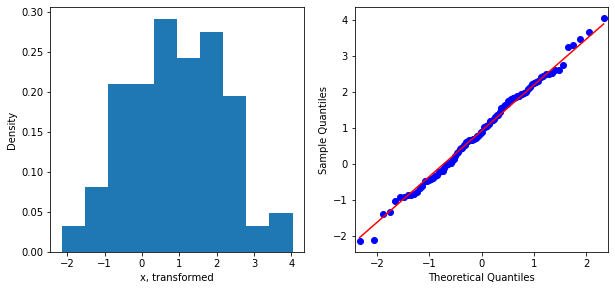

In [5]:
fig, axs = plt.subplots(1, 2, figsize=[10,4.5])
axs[0].hist(xt,density=True)
axs[0].set_xlabel("x, transformed")
axs[0].set_ylabel("Density")

qqplot(xt,line="s",ax=axs[1])
plt.show()

**Comment:** It is standard to choose a "nice" value of $\lambda$ from the 95% confidence interval and use that for the transformation. For example, if 0.5 is in the confidence interval, one would often prefer to use that instead of $\lambda = 0.43$, because the square root transform is easier to interpret. Likewise, if zero is in the interval, the log transform is typically utilized.

\newpage

**Exercise:** Consider the volume data below.

[*********************100%***********************]  1 of 1 downloaded


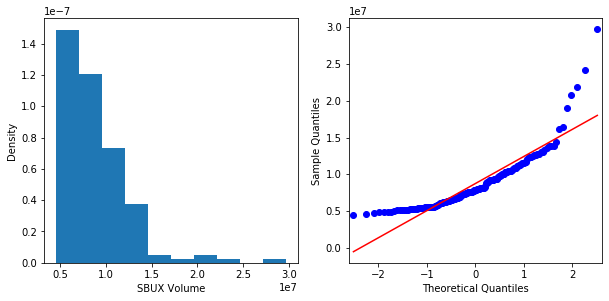

In [6]:
import yfinance as yf
SBUX = yf.download("SBUX", start="2019-01-01",
            end="2019-08-31")

fig, axs = plt.subplots(1, 2, figsize=[10,4.5])
axs[0].hist(SBUX['Volume'],density=True)
axs[0].set_xlabel("SBUX Volume")
axs[0].set_ylabel("Density")

qqplot(SBUX['Volume'],line="s", ax=axs[1])
plt.show()

Try the Box-Cox transformation in this case. What happens?

\answerlines{10}

\newpage

## Box-Cox for Regression {-}

The original motivation for this type of transformation was in the
context of the linear regression model
\begin{equation*}
   Y^{(\lambda)} = \beta_0 + \sum_{j=1}^p \beta_j x_j + \epsilon
\end{equation*}

The question posed by Box and Cox was as follows:
What choice of $\lambda$ yields the best fitting
model, if we want to assume the errors are i.i.d. Normal?

Through a maximum likelihood procedure, the best $\lambda$ can be found,
and then this choice is used to transform the response prior to
fitting the full regression model.

**Exercise:** The Python function `boxcox()` described above operates on a
single vector. How could that be used in the context of this regression
problem?

\answerlines{8}

\newpage

## Calling R from Python {-}

For all of the appeal of Python, R is definitely better suited for certain statistical and machine learning procedures. It is possible to take advantage of these capabilities directly through Python, using the package `rpy2`.

There are different ways of doing this. Here we will show an approach which allows you to embed chunks of R code within the Jupyter notebook, and pass objects back and forth as needed.

First, load the needed package, and load the interactive extension using the following two commands.

In [7]:
import rpy2
%load_ext rpy2.ipython

R does not like variable names with spaces in them.

In [8]:
SBUX = SBUX.rename(columns=\
        {"Adj Close": "AdjClose"})

The R function `boxcox` that is part of the package `MASS` implements the Box-Cox procedure. Note that here, we only need to look at the plot, so no objects are returned from the R code. To return objects, use the argument `-o` in the first line. We see examples of that later.

\newpage

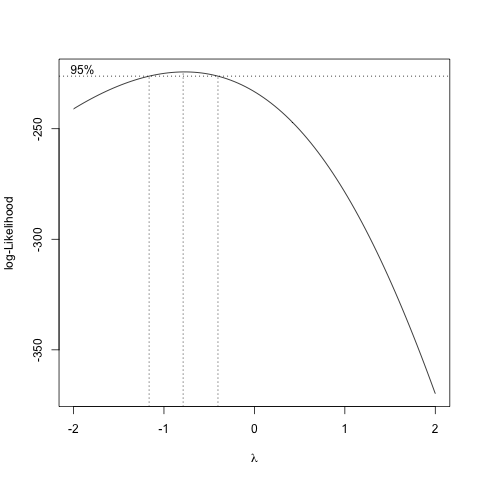

In [9]:
%%R -i SBUX

library(MASS)
boxcox(Volume~AdjClose, data=SBUX)

\newpage

**Exercise:** What conclusion do you draw from this analysis?

\answerlines{7}

**Exercise:** Fit the linear model using an appropriate transformation of the response. Assess the results.

\answerlines{10}

\newpage

## The Yeo-Johnson Transformation {-}

The Box-Cox Transformation suffers from the limitation that it can
only be applied to strictly positive variables. A generalization
that works for any variable is the **Yeo-Johnson Transformation**.

The Yeo-Johnson Power Transformation is
\begin{equation*}
   y^{(\lambda,\mbox{\small YJ})} 
   =
   \left\{
   \begin{array}{ll}
   \left(\left(y+1\right)^{\lambda}-1\right)/\lambda, & \mbox{if $\lambda \neq 0, y \geq 0$} \\
   \log\!\left(y + 1\right), & \mbox{if $\lambda = 0, y \geq 0$} \\
   - \left[\left(-y + 1\right)^{2-\lambda} -1  \right]/\left(2-\lambda\right), & \mbox{if $\lambda \neq 2, y < 0$} \\
   - \log\!\left(-y + 1\right),  & \mbox{if $\lambda = 2, y < 0$}
   \end{array}
   \right.
\end{equation*}

It appears somewhat messy, but the intention is much like for the Box-Cox Transformation:
As $\lambda$ varies, we get a wide range of power and log transformations of the data;
the optimal transformation can be sought via maximum likelihood.

In Python this is implemented in `scipy.stats.yeojohnson`.